In [2]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증'
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 차원 축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn.cluster import estimate_bandwidth

# 학습 모델 저장을 위한 라이브러리
import pickle

### 데이터 불러오기

In [3]:
df11=pd.read_parquet(r'data/train/1.회원정보/201807_train_.parquet', columns=['ID', '기준년월',
    '이용금액_R3M_신용체크','_1순위카드이용금액','이용금액_R3M_신용',
    '이용카드수_신용체크', '이용카드수_신용', '_1순위카드이용건수', 'Life_Stage', '연령'
])
df12=pd.read_parquet(r'data/train/1.회원정보/201808_train_.parquet', columns=['ID', '기준년월',
    '이용금액_R3M_신용체크','_1순위카드이용금액','이용금액_R3M_신용',
    '이용카드수_신용체크', '이용카드수_신용', '_1순위카드이용건수', 'Life_Stage', '연령'
])
df13=pd.read_parquet(r'data/train/1.회원정보/201809_train_.parquet', columns=['ID', '기준년월',
    '이용금액_R3M_신용체크','_1순위카드이용금액','이용금액_R3M_신용',
    '이용카드수_신용체크', '이용카드수_신용', '_1순위카드이용건수', 'Life_Stage', '연령'
])
df14=pd.read_parquet(r'data/train/1.회원정보/201810_train_.parquet', columns=['ID', '기준년월',
    '이용금액_R3M_신용체크','_1순위카드이용금액','이용금액_R3M_신용',
    '이용카드수_신용체크', '이용카드수_신용', '_1순위카드이용건수', 'Life_Stage', '연령'
])
df15=pd.read_parquet(r'data/train/1.회원정보/201811_train_.parquet', columns=['ID', '기준년월',
    '이용금액_R3M_신용체크','_1순위카드이용금액','이용금액_R3M_신용',
    '이용카드수_신용체크', '이용카드수_신용', '_1순위카드이용건수', 'Life_Stage', '연령'
])
df16=pd.read_parquet(r'data/train/1.회원정보/201812_train_.parquet', columns=['ID', '기준년월',
    '이용금액_R3M_신용체크','_1순위카드이용금액','이용금액_R3M_신용',
    '이용카드수_신용체크', '이용카드수_신용', '_1순위카드이용건수', 'Life_Stage', '연령'
])

In [4]:
all_df1 = pd.concat([df11, df12, df13, df14, df15, df16])
all_df1.reset_index(inplace=True, drop=True)
all_df1

,ID,기준년월,이용금액_R3M_신용체크,_1순위카드이용금액,이용금액_R3M_신용,이용카드수_신용체크,이용카드수_신용,_1순위카드이용건수,Life_Stage,연령
0,TRAIN_000000,201807,196,3681,196,1,1,26,자녀성장(2),40대
1,TRAIN_000001,201807,13475,13323,13475,1,1,46,자녀성장(1),30대
2,TRAIN_000002,201807,23988,24493,23988,1,1,28,자녀출산기,30대
3,TRAIN_000003,201807,3904,5933,3904,1,1,1,자녀성장(2),40대
4,TRAIN_000004,201807,1190,0,0,1,0,-2,자녀성장(1),40대
...,...,...,...,...,...,...,...,...,...,...
2399995,TRAIN_399995,201812,10755,5640,7267,1,0,3,노년생활,70대이상
2399996,TRAIN_399996,201812,27636,26357,27636,1,1,38,자녀성장(2),50대
2399997,TRAIN_399997,201812,23187,17171,23187,1,1,33,자녀출산기,30대
2399998,TRAIN_399998,201812,0,0,0,0,0,-2,자녀성장(1),40대


In [5]:
df311=pd.read_parquet(r'data/train/3.승인매출정보/201807_train_.parquet',columns=['ID','기준년월',
    '이용금액_오프라인_B0M','정상청구원금_B5M','정상청구원금_B0M',
    '정상청구원금_B2M','이용개월수_신용_R12M','연속유실적개월수_기본_24M_카드',
    '이용개월수_신판_R12M','이용개월수_일시불_R12M','이용금액_일시불_R6M',
    '이용금액_일시불_R3M','이용금액_일시불_B0M','이용건수_신용_R12M','이용건수_신판_R12M',
    '이용금액_오프라인_R3M','이용건수_일시불_R12M','이용가맹점수','이용금액_일시불_R12M',
    '이용개월수_전체_R6M','이용금액_오프라인_R6M','이용건수_오프라인_B0M',
    '이용건수_신용_R6M','이용건수_신용_B0M','_2순위쇼핑업종_이용금액','이용건수_신판_R6M',
    '이용건수_신용_R3M','이용건수_신판_B0M','이용건수_일시불_R6M','이용건수_신판_R3M',
    '이용건수_일시불_B0M','이용건수_일시불_R3M','_3순위쇼핑업종_이용금액','정상입금원금_B0M',
    '_3순위업종_이용금액','이용개월수_전체_R3M','이용건수_오프라인_R3M','이용후경과월_신용',
    '_2순위업종_이용금액','이용개월수_신용_R6M','정상입금원금_B2M','정상입금원금_B5M'
])
df312=pd.read_parquet(r'data/train/3.승인매출정보/201808_train_.parquet',columns=['ID','기준년월',
    '이용금액_오프라인_B0M','정상청구원금_B5M','정상청구원금_B0M',
    '정상청구원금_B2M','이용개월수_신용_R12M','연속유실적개월수_기본_24M_카드',
    '이용개월수_신판_R12M','이용개월수_일시불_R12M','이용금액_일시불_R6M',
    '이용금액_일시불_R3M','이용금액_일시불_B0M','이용건수_신용_R12M','이용건수_신판_R12M',
    '이용금액_오프라인_R3M','이용건수_일시불_R12M','이용가맹점수','이용금액_일시불_R12M',
    '이용개월수_전체_R6M','이용금액_오프라인_R6M','이용건수_오프라인_B0M',
    '이용건수_신용_R6M','이용건수_신용_B0M','_2순위쇼핑업종_이용금액','이용건수_신판_R6M',
    '이용건수_신용_R3M','이용건수_신판_B0M','이용건수_일시불_R6M','이용건수_신판_R3M',
    '이용건수_일시불_B0M','이용건수_일시불_R3M','_3순위쇼핑업종_이용금액','정상입금원금_B0M',
    '_3순위업종_이용금액','이용개월수_전체_R3M','이용건수_오프라인_R3M','이용후경과월_신용',
    '_2순위업종_이용금액','이용개월수_신용_R6M','정상입금원금_B2M','정상입금원금_B5M'
])
df313=pd.read_parquet(r'data/train/3.승인매출정보/201809_train_.parquet',columns=['ID','기준년월',
    '이용금액_오프라인_B0M','정상청구원금_B5M','정상청구원금_B0M',
    '정상청구원금_B2M','이용개월수_신용_R12M','연속유실적개월수_기본_24M_카드',
    '이용개월수_신판_R12M','이용개월수_일시불_R12M','이용금액_일시불_R6M',
    '이용금액_일시불_R3M','이용금액_일시불_B0M','이용건수_신용_R12M','이용건수_신판_R12M',
    '이용금액_오프라인_R3M','이용건수_일시불_R12M','이용가맹점수','이용금액_일시불_R12M',
    '이용개월수_전체_R6M','이용금액_오프라인_R6M','이용건수_오프라인_B0M',
    '이용건수_신용_R6M','이용건수_신용_B0M','_2순위쇼핑업종_이용금액','이용건수_신판_R6M',
    '이용건수_신용_R3M','이용건수_신판_B0M','이용건수_일시불_R6M','이용건수_신판_R3M',
    '이용건수_일시불_B0M','이용건수_일시불_R3M','_3순위쇼핑업종_이용금액','정상입금원금_B0M',
    '_3순위업종_이용금액','이용개월수_전체_R3M','이용건수_오프라인_R3M','이용후경과월_신용',
    '_2순위업종_이용금액','이용개월수_신용_R6M','정상입금원금_B2M','정상입금원금_B5M'
])

In [6]:
df314=pd.read_parquet(r'data/train/3.승인매출정보/201810_train_.parquet',columns=['ID','기준년월',
    '이용금액_오프라인_B0M','정상청구원금_B5M','정상청구원금_B0M',
    '정상청구원금_B2M','이용개월수_신용_R12M','연속유실적개월수_기본_24M_카드',
    '이용개월수_신판_R12M','이용개월수_일시불_R12M','이용금액_일시불_R6M',
    '이용금액_일시불_R3M','이용금액_일시불_B0M','이용건수_신용_R12M','이용건수_신판_R12M',
    '이용금액_오프라인_R3M','이용건수_일시불_R12M','이용가맹점수','이용금액_일시불_R12M',
    '이용개월수_전체_R6M','이용금액_오프라인_R6M','이용건수_오프라인_B0M',
    '이용건수_신용_R6M','이용건수_신용_B0M','_2순위쇼핑업종_이용금액','이용건수_신판_R6M',
    '이용건수_신용_R3M','이용건수_신판_B0M','이용건수_일시불_R6M','이용건수_신판_R3M',
    '이용건수_일시불_B0M','이용건수_일시불_R3M','_3순위쇼핑업종_이용금액','정상입금원금_B0M',
    '_3순위업종_이용금액','이용개월수_전체_R3M','이용건수_오프라인_R3M','이용후경과월_신용',
    '_2순위업종_이용금액','이용개월수_신용_R6M','정상입금원금_B2M','정상입금원금_B5M'
])
df315=pd.read_parquet(r'data/train/3.승인매출정보/201811_train_.parquet',columns=['ID','기준년월',
    '이용금액_오프라인_B0M','정상청구원금_B5M','정상청구원금_B0M',
    '정상청구원금_B2M','이용개월수_신용_R12M','연속유실적개월수_기본_24M_카드',
    '이용개월수_신판_R12M','이용개월수_일시불_R12M','이용금액_일시불_R6M',
    '이용금액_일시불_R3M','이용금액_일시불_B0M','이용건수_신용_R12M','이용건수_신판_R12M',
    '이용금액_오프라인_R3M','이용건수_일시불_R12M','이용가맹점수','이용금액_일시불_R12M',
    '이용개월수_전체_R6M','이용금액_오프라인_R6M','이용건수_오프라인_B0M',
    '이용건수_신용_R6M','이용건수_신용_B0M','_2순위쇼핑업종_이용금액','이용건수_신판_R6M',
    '이용건수_신용_R3M','이용건수_신판_B0M','이용건수_일시불_R6M','이용건수_신판_R3M',
    '이용건수_일시불_B0M','이용건수_일시불_R3M','_3순위쇼핑업종_이용금액','정상입금원금_B0M',
    '_3순위업종_이용금액','이용개월수_전체_R3M','이용건수_오프라인_R3M','이용후경과월_신용',
    '_2순위업종_이용금액','이용개월수_신용_R6M','정상입금원금_B2M','정상입금원금_B5M'
])
df316=pd.read_parquet(r'data/train/3.승인매출정보/201812_train_.parquet',columns=['ID','기준년월',
    '이용금액_오프라인_B0M','정상청구원금_B5M','정상청구원금_B0M',
    '정상청구원금_B2M','이용개월수_신용_R12M','연속유실적개월수_기본_24M_카드',
    '이용개월수_신판_R12M','이용개월수_일시불_R12M','이용금액_일시불_R6M',
    '이용금액_일시불_R3M','이용금액_일시불_B0M','이용건수_신용_R12M','이용건수_신판_R12M',
    '이용금액_오프라인_R3M','이용건수_일시불_R12M','이용가맹점수','이용금액_일시불_R12M',
    '이용개월수_전체_R6M','이용금액_오프라인_R6M','이용건수_오프라인_B0M',
    '이용건수_신용_R6M','이용건수_신용_B0M','_2순위쇼핑업종_이용금액','이용건수_신판_R6M',
    '이용건수_신용_R3M','이용건수_신판_B0M','이용건수_일시불_R6M','이용건수_신판_R3M',
    '이용건수_일시불_B0M','이용건수_일시불_R3M','_3순위쇼핑업종_이용금액','정상입금원금_B0M',
    '_3순위업종_이용금액','이용개월수_전체_R3M','이용건수_오프라인_R3M','이용후경과월_신용',
    '_2순위업종_이용금액','이용개월수_신용_R6M','정상입금원금_B2M','정상입금원금_B5M'
])

In [7]:
all_df3 = pd.concat([df311, df312, df313, df314, df315, df316])
all_df3.reset_index(inplace=True, drop=True)
all_df3

,ID,기준년월,이용금액_오프라인_B0M,정상청구원금_B5M,정상청구원금_B0M,정상청구원금_B2M,이용개월수_신용_R12M,연속유실적개월수_기본_24M_카드,이용개월수_신판_R12M,이용개월수_일시불_R12M,...,_3순위쇼핑업종_이용금액,정상입금원금_B0M,_3순위업종_이용금액,이용개월수_전체_R3M,이용건수_오프라인_R3M,이용후경과월_신용,_2순위업종_이용금액,이용개월수_신용_R6M,정상입금원금_B2M,정상입금원금_B5M
0,TRAIN_000000,201807,4043,14958,14440,16524,12,13,12,12,...,0,6335,672,3,17,0,1408,6,16125,9205
1,TRAIN_000001,201807,3980,3367,6024,2420,12,12,12,12,...,315,5198,1659,3,51,0,2083,6,2420,2546
2,TRAIN_000002,201807,4524,23963,21929,21826,9,8,9,9,...,924,12564,1362,3,33,0,1539,6,14448,16949
3,TRAIN_000003,201807,3975,19614,18563,19172,12,5,12,7,...,0,7639,774,3,19,0,2284,6,13043,8418
4,TRAIN_000004,201807,0,0,0,272,1,0,1,1,...,0,0,0,0,0,6,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,TRAIN_399995,201812,0,0,19,0,3,0,0,0,...,0,0,0,0,0,8,0,0,0,0
2399996,TRAIN_399996,201812,4676,23742,13462,14844,12,17,12,12,...,346,9705,1547,3,24,0,1810,6,10764,21831
2399997,TRAIN_399997,201812,4516,4125,7049,6862,12,24,12,12,...,305,5346,2302,3,32,1,2315,6,6106,3269
2399998,TRAIN_399998,201812,0,507,0,0,0,0,0,0,...,0,0,0,0,0,12,0,0,0,0


In [9]:
df41=pd.read_parquet(r'data/train/4.청구입금정보/201807_train_.parquet', columns=['ID','기준년월',
    '청구금액_R6M',
    '청구금액_R3M',
    '청구금액_B0',
    '청구서발송여부_B0'
])
df42=pd.read_parquet(r'data/train/4.청구입금정보/201808_train_.parquet', columns=['ID','기준년월',
    '청구금액_R6M',
    '청구금액_R3M',
    '청구금액_B0',
    '청구서발송여부_B0'
])
df43=pd.read_parquet(r'data/train/4.청구입금정보/201809_train_.parquet', columns=['ID','기준년월',
    '청구금액_R6M',
    '청구금액_R3M',
    '청구금액_B0',
    '청구서발송여부_B0'
])
df44=pd.read_parquet(r'data/train/4.청구입금정보/201810_train_.parquet', columns=['ID','기준년월',
    '청구금액_R6M',
    '청구금액_R3M',
    '청구금액_B0',
    '청구서발송여부_B0'
])
df45=pd.read_parquet(r'data/train/4.청구입금정보/201811_train_.parquet', columns=['ID','기준년월',
    '청구금액_R6M',
    '청구금액_R3M',
    '청구금액_B0',
    '청구서발송여부_B0'
])
df46=pd.read_parquet(r'data/train/4.청구입금정보/201812_train_.parquet', columns=['ID','기준년월',
    '청구금액_R6M',
    '청구금액_R3M',
    '청구금액_B0',
    '청구서발송여부_B0'
])

In [10]:
all_df4 = pd.concat([df41, df42, df43, df44, df45, df46])
all_df4.reset_index(inplace=True, drop=True)
all_df4

,ID,기준년월,청구금액_R6M,청구금액_R3M,청구금액_B0,청구서발송여부_B0
0,TRAIN_000000,201807,88693,46588,12226,1
1,TRAIN_000001,201807,16861,10530,5834,1
2,TRAIN_000002,201807,165221,85931,21866,1
3,TRAIN_000003,201807,127371,61518,16356,1
4,TRAIN_000004,201807,155,0,0,0
...,...,...,...,...,...,...
2399995,TRAIN_399995,201812,0,0,0,0
2399996,TRAIN_399996,201812,99849,37515,14402,1
2399997,TRAIN_399997,201812,41073,22274,5731,1
2399998,TRAIN_399998,201812,0,0,0,0


In [22]:
train_df = all_df3.merge(all_df1, on=['ID', '기준년월'], how='inner')
train_df = all_df4.merge(train_df, on=['ID', '기준년월'], how='inner')

In [16]:
target1=pd.read_parquet(r'data/train/1.회원정보/201807_train_.parquet')
target2=pd.read_parquet(r'data/train/1.회원정보/201808_train_.parquet')
target3=pd.read_parquet(r'data/train/1.회원정보/201809_train_.parquet')
target4=pd.read_parquet(r'data/train/1.회원정보/201810_train_.parquet')
target5=pd.read_parquet(r'data/train/1.회원정보/201811_train_.parquet')
target6=pd.read_parquet(r'data/train/1.회원정보/201812_train_.parquet')

In [17]:
tg_df = pd.concat([target1['Segment'], target2['Segment'], target3['Segment'], target4['Segment'], target5['Segment'], target6['Segment']])
tg_df.reset_index(inplace=True, drop=True)
tg_df

0          D
1          E
2          C
3          D
4          E
          ..
2399995    E
2399996    D
2399997    C
2399998    E
2399999    E
Name: Segment, Length: 2400000, dtype: object

In [23]:
train_df['Segment'] = tg_df

In [24]:
train_df['Segment'] = train_df['Segment'].apply(lambda x: 'E' if x == 'E' else 'notE')

In [25]:
train_df

,ID,기준년월,청구금액_R6M,청구금액_R3M,청구금액_B0,청구서발송여부_B0,이용금액_오프라인_B0M,정상청구원금_B5M,정상청구원금_B0M,정상청구원금_B2M,...,정상입금원금_B5M,이용금액_R3M_신용체크,_1순위카드이용금액,이용금액_R3M_신용,이용카드수_신용체크,이용카드수_신용,_1순위카드이용건수,Life_Stage,연령,Segment
0,TRAIN_000000,201807,88693,46588,12226,1,4043,14958,14440,16524,...,9205,196,3681,196,1,1,26,자녀성장(2),40대,notE
1,TRAIN_000001,201807,16861,10530,5834,1,3980,3367,6024,2420,...,2546,13475,13323,13475,1,1,46,자녀성장(1),30대,E
2,TRAIN_000002,201807,165221,85931,21866,1,4524,23963,21929,21826,...,16949,23988,24493,23988,1,1,28,자녀출산기,30대,notE
3,TRAIN_000003,201807,127371,61518,16356,1,3975,19614,18563,19172,...,8418,3904,5933,3904,1,1,1,자녀성장(2),40대,notE
4,TRAIN_000004,201807,155,0,0,0,0,0,0,272,...,0,1190,0,0,1,0,-2,자녀성장(1),40대,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,TRAIN_399995,201812,0,0,0,0,0,0,19,0,...,0,10755,5640,7267,1,0,3,노년생활,70대이상,E
2399996,TRAIN_399996,201812,99849,37515,14402,1,4676,23742,13462,14844,...,21831,27636,26357,27636,1,1,38,자녀성장(2),50대,notE
2399997,TRAIN_399997,201812,41073,22274,5731,1,4516,4125,7049,6862,...,3269,23187,17171,23187,1,1,33,자녀출산기,30대,notE
2399998,TRAIN_399998,201812,0,0,0,0,0,507,0,0,...,0,0,0,0,0,0,-2,자녀성장(1),40대,E


In [26]:
train_df = train_df.drop(['ID', '기준년월'], axis=1)

In [27]:
train_df

,청구금액_R6M,청구금액_R3M,청구금액_B0,청구서발송여부_B0,이용금액_오프라인_B0M,정상청구원금_B5M,정상청구원금_B0M,정상청구원금_B2M,이용개월수_신용_R12M,연속유실적개월수_기본_24M_카드,...,정상입금원금_B5M,이용금액_R3M_신용체크,_1순위카드이용금액,이용금액_R3M_신용,이용카드수_신용체크,이용카드수_신용,_1순위카드이용건수,Life_Stage,연령,Segment
0,88693,46588,12226,1,4043,14958,14440,16524,12,13,...,9205,196,3681,196,1,1,26,자녀성장(2),40대,notE
1,16861,10530,5834,1,3980,3367,6024,2420,12,12,...,2546,13475,13323,13475,1,1,46,자녀성장(1),30대,E
2,165221,85931,21866,1,4524,23963,21929,21826,9,8,...,16949,23988,24493,23988,1,1,28,자녀출산기,30대,notE
3,127371,61518,16356,1,3975,19614,18563,19172,12,5,...,8418,3904,5933,3904,1,1,1,자녀성장(2),40대,notE
4,155,0,0,0,0,0,0,272,1,0,...,0,1190,0,0,1,0,-2,자녀성장(1),40대,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,0,0,0,0,0,0,19,0,3,0,...,0,10755,5640,7267,1,0,3,노년생활,70대이상,E
2399996,99849,37515,14402,1,4676,23742,13462,14844,12,17,...,21831,27636,26357,27636,1,1,38,자녀성장(2),50대,notE
2399997,41073,22274,5731,1,4516,4125,7049,6862,12,24,...,3269,23187,17171,23187,1,1,33,자녀출산기,30대,notE
2399998,0,0,0,0,0,507,0,0,0,0,...,0,0,0,0,0,0,-2,자녀성장(1),40대,E


In [28]:
# 인코딩할 컬럼 리스트
factor_cols = [
    'Life_Stage', '연령'
]

# 매핑 사전 저장용 딕셔너리
encoders = {}

# train_df에 factorize 적용 + 매핑 저장
for col in factor_cols:
    codes, uniques = pd.factorize(train_df[col])
    train_df[col] = codes
    encoders[col] = {val: idx for idx, val in enumerate(uniques)}

In [37]:
# # 입력데이터의 X 의 컬럼의 개수가 많으면 각각의 조합으로 모두 시각화 해봐야 한다.
# # pairplot 사용
# sns.pairplot(data=train_df, hue='Segment')
# plt.show()

In [29]:
# pca 사용
# n_components : 축소될 결과의 컬럼 개수
pca = PCA(n_components=25)
# 결과 데이터를 제거한다. 
X = train_df.drop('Segment', axis=1)
# 학습한다.
pca.fit(X)
# 데이터를 변환한다.
r1 = pca.transform(X)
r1

array([[-6.07026600e+02,  7.29259482e+04, -2.22629808e+04, ...,
         6.98214120e+01,  1.84726736e+01, -8.00242453e+00],
       [-4.02802936e+03, -1.85133704e+04, -4.93641824e+03, ...,
         1.28277856e+02, -7.61785324e+00, -4.36094149e+01],
       [ 9.40295918e+04,  1.22366487e+05, -2.07222296e+04, ...,
        -1.58321201e+02,  2.40956814e+02, -2.54141899e+01],
       ...,
       [ 1.83642969e+04,  3.08323913e+03,  6.35921123e+03, ...,
         1.92633739e+01,  3.62241368e+01, -5.80271307e+01],
       [-7.36857497e+04, -3.55074679e+03, -3.67057153e+03, ...,
        -5.57636866e+01,  2.92686063e+01, -3.07052064e+00],
       [-3.54558418e+04,  4.55391834e+03,  5.72087345e+03, ...,
        -1.54966057e+02,  4.84601156e+01, -5.53603975e+00]])

In [30]:
# 결과데이터를 붙혀서 시각화 해본다
pca_df = pd.DataFrame(r1, columns=[f'p{i+1}' for i in range(r1.shape[1])])
pca_df['Segment'] = train_df['Segment']
pca_df

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p17,p18,p19,p20,p21,p22,p23,p24,p25,Segment
0,-607.026600,72925.948157,-22262.980777,7423.126993,4212.986297,10321.198873,-4303.284902,240.599618,9719.960337,2083.925947,...,-283.245678,356.216335,3382.179619,250.756405,407.291624,-524.473099,69.821412,18.472674,-8.002425,notE
1,-4028.029358,-18513.370407,-4936.418238,-240.299702,2682.012338,4828.003315,5376.642221,-1210.256238,201.280423,685.981616,...,-116.124822,285.783484,447.724500,-321.862909,-1733.628439,-60.987328,128.277856,-7.617853,-43.609415,E
2,94029.591811,122366.487125,-20722.229598,-8099.653250,9217.539527,8413.471144,-5415.501036,2118.515075,6108.649272,6261.210239,...,1897.417816,-542.931225,849.985927,842.941970,808.694396,200.373854,-158.321201,240.956814,-25.414190,notE
3,12779.284145,114961.997979,-20393.819831,10818.189271,-9943.708845,13364.049069,5001.262667,208.071183,7121.771948,5105.168326,...,1757.455809,1164.613687,2034.156869,36.359452,423.229911,-293.721112,-4.072137,-203.752579,14.349021,notE
4,-74750.212963,-2386.530827,-1880.434689,1118.525523,-2289.655414,279.773160,-758.392291,403.719349,-755.161877,-855.287261,...,1099.435034,-574.422472,176.869389,371.609147,623.122415,-91.384506,-60.923952,36.247078,11.794511,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,-69223.101043,-4588.518123,2271.824213,-8469.916788,-6638.233091,10.333588,808.392280,1933.889067,-1547.579921,1428.280686,...,-214.531674,-159.496800,43.138822,-25.974933,-107.698111,-191.268856,48.572737,49.348539,18.201767,E
2399996,137933.537853,2603.493283,-25148.877892,15928.960044,4940.338075,-4262.112164,-1289.195419,1522.750053,12745.660975,2784.478303,...,-2441.826889,-952.891423,362.699582,-130.695662,-233.054171,-128.160669,-149.820257,-84.722314,20.979252,notE
2399997,18364.296860,3083.239132,6359.211232,-2871.622491,-219.361415,1785.180986,-600.507915,2204.584216,-1879.550235,674.370212,...,850.415306,-307.276943,411.960130,848.491303,-266.645296,-458.322748,19.263374,36.224137,-58.027131,notE
2399998,-73685.749666,-3550.746786,-3670.571534,1299.253549,-1402.636728,727.697407,-13.687284,771.692283,-923.660291,-838.454439,...,-52.932117,43.941513,57.001419,-59.839890,-98.750209,-57.121265,-55.763687,29.268606,-3.070521,E


In [31]:
# pca는 PCA 모델 객체라고 가정
import pandas as pd

pca_components = pd.DataFrame(pca.components_,
                               columns=train_df.drop('Segment', axis=1).columns,
                               index=[f'p{i+1}' for i in range(pca.n_components_)])
pca_components


,청구금액_R6M,청구금액_R3M,청구금액_B0,청구서발송여부_B0,이용금액_오프라인_B0M,정상청구원금_B5M,정상청구원금_B0M,정상청구원금_B2M,이용개월수_신용_R12M,연속유실적개월수_기본_24M_카드,...,정상입금원금_B2M,정상입금원금_B5M,이용금액_R3M_신용체크,_1순위카드이용금액,이용금액_R3M_신용,이용카드수_신용체크,이용카드수_신용,_1순위카드이용건수,Life_Stage,연령
p1,0.421242,0.200826,0.064700,1.646814e-06,0.040068,0.062903,0.058191,0.060723,0.000020,0.000049,...,0.045974,0.049574,0.207636,0.135089,0.206186,0.000005,0.000005,0.000374,-1.199407e-06,-1.737615e-06
p2,0.768386,0.339598,0.104506,9.542351e-07,-0.002312,0.051383,0.053584,0.058572,0.000004,0.000005,...,0.032511,0.024136,-0.052574,-0.019189,-0.046657,-0.000001,-0.000001,-0.000129,-4.966346e-07,3.117201e-06
p3,-0.216138,0.009309,0.010333,3.176036e-06,0.059623,-0.032605,0.024076,0.021344,0.000015,0.000032,...,0.003846,-0.045463,0.313528,0.138042,0.244226,0.000011,0.000009,0.000469,2.305264e-06,4.191419e-07
p4,0.072723,-0.118943,-0.065824,-1.197290e-06,-0.015018,-0.004457,-0.046277,-0.016585,-0.000006,-0.000039,...,-0.006933,0.007524,-0.593354,-0.084792,-0.400543,-0.000024,-0.000018,-0.000371,-4.196711e-06,9.814473e-06
p5,-0.083023,0.167128,0.059242,6.673667e-06,0.074400,-0.020595,0.042219,0.044631,0.000047,0.000066,...,0.035380,-0.031794,-0.488942,0.150370,-0.115109,-0.000019,-0.000009,0.001232,-7.442704e-06,-5.947855e-06
p6,-0.390663,0.745061,0.264495,-2.257004e-06,-0.001315,0.018815,0.105450,0.077820,-0.000034,-0.000026,...,0.129476,0.043495,-0.120440,0.080369,0.018200,-0.000012,-0.000008,-0.000130,-3.195347e-06,6.629968e-06
p7,0.107829,-0.233975,-0.034290,1.288857e-06,0.106278,0.008101,0.051737,-0.028884,0.000007,0.000068,...,-0.127336,-0.075371,-0.188812,0.225931,0.217645,-0.000012,-0.000001,0.000399,9.001847e-07,5.153338e-06
p8,-0.001176,-0.155867,0.010584,-4.533114e-06,-0.035493,0.139359,0.066682,0.061526,-0.000065,-0.000044,...,0.118556,0.217920,-0.437328,0.112990,0.729029,-0.000010,0.000023,-0.000428,1.073398e-06,1.691281e-05
p9,-0.034371,-0.213043,-0.006089,9.080060e-06,0.037163,0.367720,0.135259,0.180602,0.000090,0.000137,...,0.394404,0.606792,0.140050,0.005259,-0.271909,0.000006,-0.000005,-0.000018,-1.090133e-05,1.683482e-05
p10,-0.033394,-0.091324,0.026142,1.008267e-05,0.017519,0.341033,0.374588,0.342441,0.000030,-0.000104,...,-0.234421,-0.220910,0.047278,0.610634,-0.209143,-0.000045,-0.000056,0.000032,1.598992e-05,5.989136e-06


In [32]:
# 절댓값 기준 가장 영향 큰 변수들 보기 (상위 5개씩)
for i in range(pca_components.shape[0]):
    print(f"\n📌 주성분 p{i+1}")
    print(pca_components.iloc[i].abs().sort_values(ascending=False).head(5))



📌 주성분 p1
이용금액_일시불_R12M    0.664978
청구금액_R6M         0.421242
이용금액_오프라인_R6M    0.313624
이용금액_일시불_R6M     0.274072
이용금액_R3M_신용체크    0.207636
Name: p1, dtype: float64

📌 주성분 p2
청구금액_R6M         0.768386
이용금액_일시불_R12M    0.494952
청구금액_R3M         0.339598
이용금액_일시불_R6M     0.120381
청구금액_B0          0.104506
Name: p2, dtype: float64

📌 주성분 p3
이용금액_오프라인_R6M    0.608906
이용금액_일시불_R12M    0.518229
이용금액_R3M_신용체크    0.313528
이용금액_오프라인_R3M    0.283826
이용금액_R3M_신용      0.244226
Name: p3, dtype: float64

📌 주성분 p4
이용금액_오프라인_R6M    0.633747
이용금액_R3M_신용체크    0.593354
이용금액_R3M_신용      0.400543
이용금액_일시불_R6M     0.144406
청구금액_R3M         0.118943
Name: p4, dtype: float64

📌 주성분 p5
이용금액_일시불_R6M     0.688560
이용금액_R3M_신용체크    0.488942
이용금액_일시불_R3M     0.316069
이용금액_오프라인_R6M    0.234049
청구금액_R3M         0.167128
Name: p5, dtype: float64

📌 주성분 p6
청구금액_R3M        0.745061
청구금액_R6M        0.390663
이용금액_일시불_R6M    0.338898
청구금액_B0         0.264495
정상입금원금_B0M      0.135195
Name: p6, dtype: float64

📌 주성분 p7
이용금액_

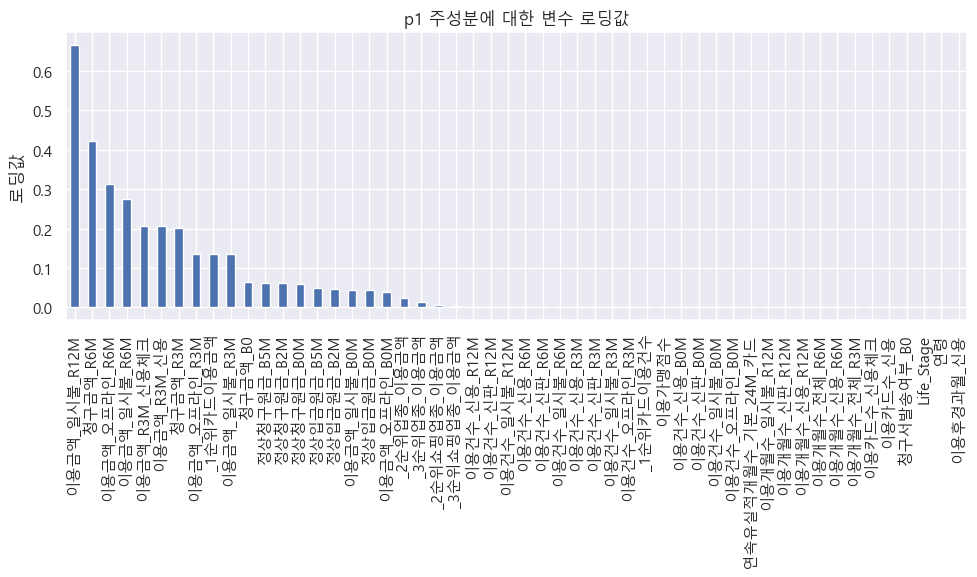

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
pca_components.loc['p1'].sort_values(ascending=False).plot(kind='bar')
plt.title('p1 주성분에 대한 변수 로딩값')
plt.ylabel('로딩값')
plt.tight_layout()
plt.show()


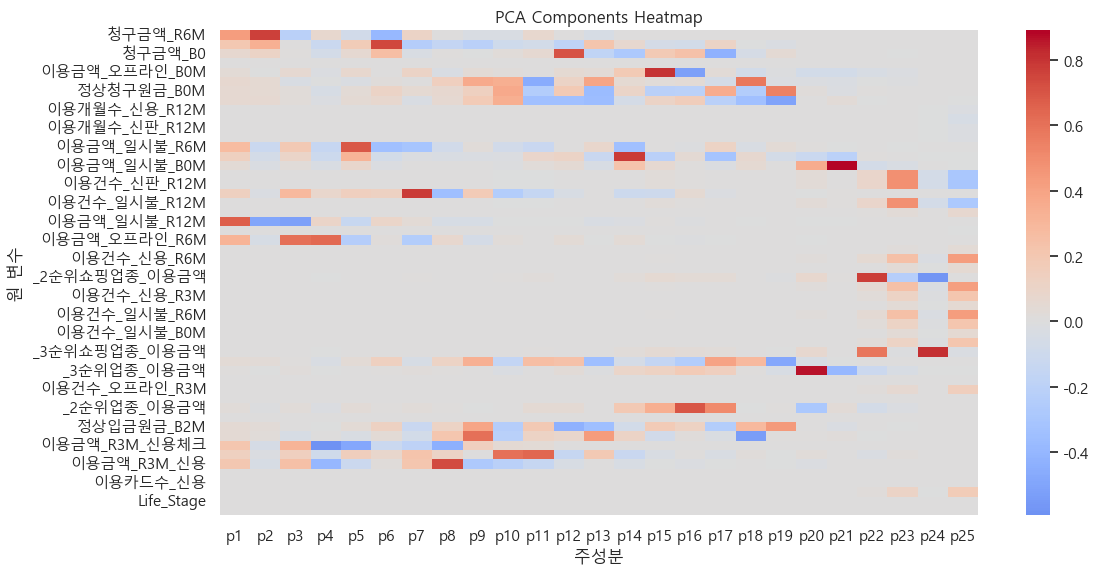

In [34]:
plt.figure(figsize=(12, 6))
sns.heatmap(pca_components.T, cmap='coolwarm', center=0)
plt.title('PCA Components Heatmap')
plt.xlabel('주성분')
plt.ylabel('원 변수')
plt.tight_layout()
plt.show()


In [35]:
# 차원축소
# PCA
pca = PCA(n_components=27)
pca_X = pca.fit_transform(X)

In [36]:
X = train_df.drop('Segment', axis=1)
y = train_df['Segment']

In [37]:
from sklearn.preprocessing import LabelEncoder

# 문자형 Segment를 숫자형으로 변환
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [38]:
print(le.classes_)
# 출력 예시: ['A' 'B' 'C' 'D' 'E']

['E' 'notE']


In [39]:
# 교차검증을 통해 확인해본다.
model1 = XGBClassifier(slient=True, verbosity=0)
model2 = XGBClassifier(slient=True, verbosity=0)

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

r1 = cross_val_score(model1, X, y_encoded, scoring='accuracy', cv=kfold)
r2 = cross_val_score(model1, pca_X, y_encoded, scoring='accuracy', cv=kfold)

print(r1.mean())
print(r2.mean())

0.9196349999999999
0.9101383333333333


---

### TEST 데이터 변환

In [40]:
test_df = pd.read_parquet(r'data/ab_cde_test.parquet')

In [41]:
test_df = test_df.drop(['ID', '기준년월'], axis=1)

In [42]:
# test_df에 train_df 기준 매핑 적용
for col in factor_cols:
    test_df[col] = test_df[col].map(encoders[col]).fillna(-1).astype(int)

In [45]:
pca_columns = X.columns.tolist()

In [46]:
# test 데이터에서 'Segment' 제외 (보통은 test에 Segment가 없을 수도 있음)
X_test = test_df.drop('Segment', axis=1, errors='ignore')

X_test = test_df[pca_columns]  # 누락 컬럼 있으면 에러 날 수 있음
X_test_pca = pca.transform(X_test)

In [47]:
# 결과데이터를 붙혀서 시각화 해본다
pca_df_test = pd.DataFrame(X_test_pca, columns=[f'p{i+1}' for i in range(X_test_pca.shape[1])])
pca_df_test

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p18,p19,p20,p21,p22,p23,p24,p25,p26,p27
0,3950.664937,-14278.618594,8893.287556,-6075.208609,5265.251391,-672.631286,7225.587533,-1518.834822,-1578.870895,-1275.032807,...,526.911711,870.900647,226.000897,821.718075,-137.398675,-361.838510,31.440014,-22.514792,4.379087,26.582893
1,-39224.634968,26261.227955,721.621848,-9178.298151,-15371.662684,12401.623555,4437.216799,1326.003373,3967.640588,5461.124111,...,918.849333,228.220923,633.212807,-184.889164,789.344288,-156.357791,241.679905,29.702419,6.608880,20.861196
2,92029.694516,19530.859613,49695.838977,13435.638608,684.391555,12885.932112,-94.928231,298.017214,2729.274601,-5194.494852,...,15.914817,22.094566,-1046.178589,723.176569,-122.786765,574.465392,124.031714,12.310479,12.319096,9.793325
3,-59720.810870,-2645.396284,32.883190,-1091.524250,-3120.161156,4269.269717,3831.747932,534.661603,-1454.557967,-287.110659,...,-157.985982,-162.832932,21.980638,296.782045,702.019036,483.513593,-15.060329,49.433770,-46.415814,23.329428
4,-47321.713161,164.113054,7470.939368,-8009.743834,-9282.489849,4555.650219,4951.151561,2783.527571,-65.176779,212.074756,...,-241.757647,61.150130,-36.960858,-743.308556,546.940194,215.822280,160.772182,-8.885888,-10.981434,-2.407245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,-73717.629851,-3576.802341,-3654.028271,1301.501084,-1392.165662,718.150038,-17.795228,701.022792,-1110.091825,-1011.379082,...,-251.909622,64.849523,-51.519494,-88.094249,-53.073646,-47.383081,27.115774,-0.631268,0.750564,1.449577
599996,-68145.774030,-2814.971759,-1829.088338,-77.847354,-3791.833474,1549.205636,646.396964,1710.181578,-467.494430,366.198645,...,-1103.944593,-1692.133878,-111.271366,2.214116,-109.738066,5.320743,34.208759,21.496339,8.764457,-4.880557
599997,-73706.300910,-3565.920380,-3650.019818,1298.378666,-1383.773391,732.603741,-23.162269,712.423602,-1076.495240,-947.740142,...,-315.687240,-29.746403,-51.033358,-82.198555,-52.192409,-37.539264,26.244486,14.482226,1.757065,12.710415
599998,419888.717143,-148806.720685,-53629.422445,-77782.613154,-41877.767575,-11188.499218,-2662.427424,-25396.403364,-14192.503897,16878.005191,...,-2168.556953,3800.947579,-2727.367554,466.317515,91.601949,-153.925988,310.006123,44.696015,2.202333,-0.825359


In [48]:
# Parquet 파일로 저장
pca_df.to_parquet("pca_E,notE_train27.parquet", index=False)
pca_df_test.to_parquet("pca_E,notE_test27.parquet", index=False)